In [1]:
!pip install nltk wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
df=pd.read_csv(
"/content/IMDB Dataset.csv",
engine="python"
)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
import os

os.listdir("/content")

['.config', 'IMDB Dataset.csv', 'sample_data']

In [9]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [10]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [11]:
df.shape

(50000, 2)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [13]:
df.isnull().sum()

,0
review,0
sentiment,0


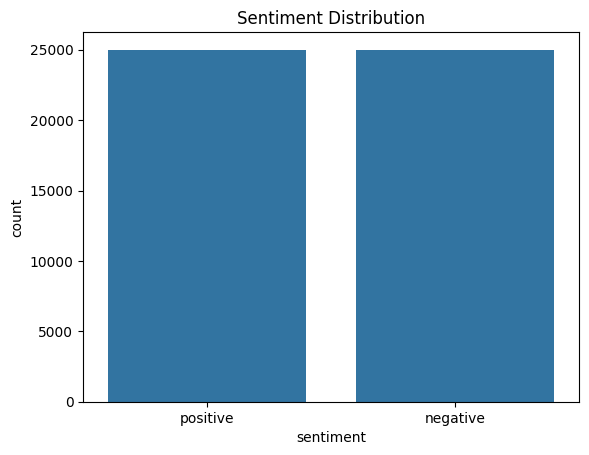

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
x="sentiment",
data=df
)

plt.title("Sentiment Distribution")

plt.show()

In [15]:
df["review_length"]=df["review"].apply(len)

df["review_length"].describe()

,review_length
count,50000.000000
mean,1309.431020
std,989.728014
min,32.000000
25%,699.000000
50%,970.000000
75%,1590.250000
max,13704.000000


In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
df["review_length"],
bins=30
)

plt.title("Review Length Distribution")

plt.xlabel("Length")

plt.ylabel("Count")

plt.show()

In [16]:
import nltk
import re

nltk.download("punkt")
nltk.download("stopwords")

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words=set(
stopwords.words("english")
)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
df["clean_review"]=df[
"review"
].apply(clean_text)

df.head()

NameError: name 'clean_text' is not defined

In [21]:
import pandas as pd
import nltk
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

stop_words=set(stopwords.words("english"))

def clean_text(text):

    text=str(text)

    text=text.lower()

    text=re.sub(r'[^a-zA-Z ]','',text)

    words=word_tokenize(text)

    words=[w for w in words if w not in stop_words]

    return " ".join(words)

df["clean_review"]=df["review"].apply(clean_text)

df.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,sentiment,review_length,clean_review
0,One of the other reviewers has mentioned that ...,positive,1761,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,998,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,926,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,748,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,petter matteis love time money visually stunni...


In [22]:
df[["review","clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [23]:
!pip install wordcloud

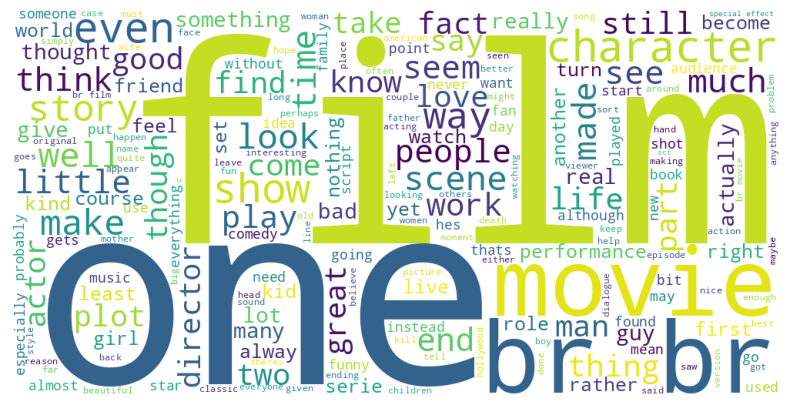

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text=" ".join(
df["clean_review"]
)

wc=WordCloud(
width=1000,
height=500,
background_color="white"
).generate(text)

plt.figure(
figsize=(10,5)
)

plt.imshow(
wc
)

plt.axis("off")

plt.show()

In [25]:
from collections import Counter

words=" ".join(
df["clean_review"]
).split()

top_words=Counter(
words
).most_common(20)

top_words

[('br', 114803),
 ('movie', 83518),
 ('film', 74455),
 ('one', 51026),
 ('like', 38989),
 ('good', 28570),
 ('even', 24574),
 ('would', 24024),
 ('time', 23267),
 ('really', 22950),
 ('see', 22534),
 ('story', 22095),
 ('much', 18945),
 ('well', 18788),
 ('get', 18204),
 ('great', 17821),
 ('also', 17818),
 ('bad', 17717),
 ('people', 17537),
 ('first', 17155)]

In [26]:
import pandas as pd

top_df=pd.DataFrame(
top_words,
columns=[
"Word",
"Count"
]
)

top_df

,Word,Count
0,br,114803
1,movie,83518
2,film,74455
3,one,51026
4,like,38989
5,good,28570
6,even,24574
7,would,24024
8,time,23267
9,really,22950


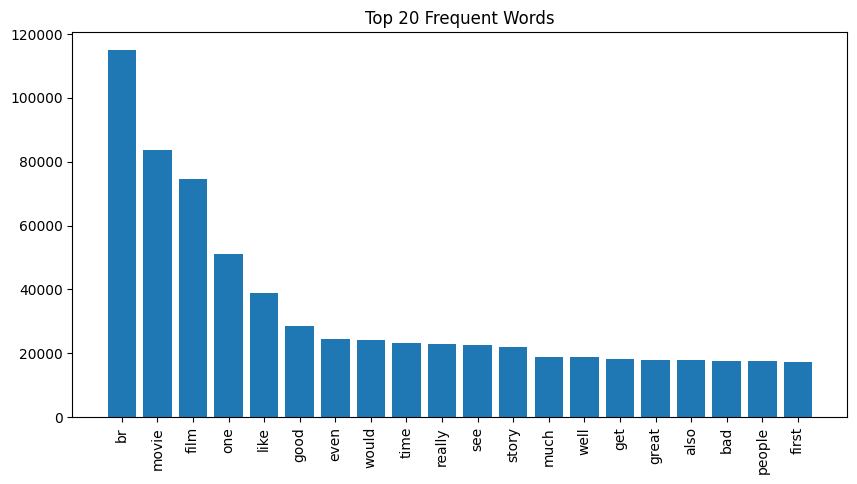

In [27]:
plt.figure(
figsize=(10,5)
)

plt.bar(
top_df["Word"],
top_df["Count"]
)

plt.xticks(
rotation=90
)

plt.title(
"Top 20 Frequent Words"
)

plt.show()

Findings
The dataset was successfully loaded and explored using Exploratory Data Analysis (EDA).
Missing values and dataset structure were analyzed.
Sentiment distribution showed the balance of positive and negative reviews.
Text preprocessing techniques such as lowercasing, tokenization, removal of stop words, and cleaning were performed.
WordCloud and frequency analysis helped identify commonly used words.
The processed dataset is now ready for further NLP and machine learning tasks.
Conclusion

This task helped in understanding the importance of Exploratory Data Analysis and preprocessing in Natural Language Processing. Data cleaning improved text quality and made the dataset suitable for future sentiment analysis and predictive modeling.